graph api vs functional api

component of langgraph
nodes
edges
state

Build A Basic Chatbot With Langgraph(GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages#reducers

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]



In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama3-8b-8192")

/home/saumya/anaconda3/envs/machinelearning/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3 8B', 'status': 'deprecated', 'release_date': '2024-04-18', 'last_updated': '2024-04-18', 'open_weights': True, 'max_input_tokens': 8192, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7613efd517f0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7613efd52510>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
llm=init_chat_model("groq:llama-3.3-70b-versatile")
llm

ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7613efdae850>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7613efdaf250>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
 ## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [8]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

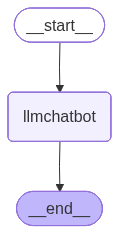

In [9]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [10]:
graph.invoke("hi")

InvalidUpdateError: Expected dict, got hi
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE

In [11]:
response=graph.invoke({"messages":"hi"})
response

{'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='99a338bb-8a43-400a-9157-8e77c2af707d'),
  AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.051558501, 'completion_tokens_details': None, 'prompt_time': 0.003960059, 'prompt_tokens_details': None, 'queue_time': 0.160867401, 'total_time': 0.05551856}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee015-7833-7790-93b8-ef82ef35845b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]}

In [12]:
response["messages"]

[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='99a338bb-8a43-400a-9157-8e77c2af707d'),
 AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.051558501, 'completion_tokens_details': None, 'prompt_time': 0.003960059, 'prompt_tokens_details': None, 'queue_time': 0.160867401, 'total_time': 0.05551856}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee015-7833-7790-93b8-ef82ef35845b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})]

In [13]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [14]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello, I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help you with any questions or topics you'd like to discuss. How about you? How's your day going?


Chatbot With Tool

In [15]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': "LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. LangChain uses a straightforward step-by-step pipeline where each task follows a fixed sequence from input to output while LangGraph allows flexible workflows with branching and parallel steps, making it better suited for complex, decision-based applications. ## Workflow of LangGraph. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. Here's a step by step interpretation of the flow:. In this example we’ll learn how to 

In [ ]:
## Custom function
 
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [ ]:
tools=[tool,multiply]#tool is defined in tavily search

In [21]:
llm_with_tool=llm.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x7613efdae850>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7613efdaf250>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you

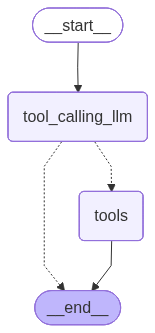

In [ ]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))
 
## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
response=graph.invoke({"messages":"what is the latest ai news"})
response['messages'][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/america-is-heading-toward-an-infinite-workweek-8911c257", "title": "America Is Heading Toward an Infinite Workweek - Let\'s Data Science", "score": 0.6617704, "published_date": "Thu, 18 Jun 2026 17:52:05 GMT", "content": "Practice interview problems based on real data\\n\\n1,500+ SQL & Python problems across 15 industry datasets — the exact type of data you work with.\\n\\nTry 250 free problems\\n\\n## More AI & Data Science News\\n\\n6.4\\n\\nJun 18\\n\\n### Human-in-the-Loop Strengthens Clinical LLM Accountability6.3\\n\\nJun 18\\n\\n### Klarna CMO Creates AI Replica for Employee Venting7.0\\n\\nJun 18\\n\\n### Sanders Introduces AI Sovereign Wealth Fund BillJun 18\\n\\n### Aether AI Raises $20 Million for Causal World Models\\n\\nView All News\\n\\nBack to News Feed\\n\\nNews on Let\'s Data Science is compiled from multiple public sources with

In [25]:
for m in response['messages']:
    m.pretty_print()
    

================================ Human Message =================================

what is the latest ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (x9rvmsrpn)
 Call ID: x9rvmsrpn
  Args:
    query: latest AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/america-is-heading-toward-an-infinite-workweek-8911c257", "title": "America Is Heading Toward an Infinite Workweek - Let's Data Science", "score": 0.6617704, "published_date": "Thu, 18 Jun 2026 17:52:05 GMT", "content": "Practice interview problems based on real data\n\n1,500+ SQL & Python problems across 15 industry datasets — the exact type of data you work with.\n\nTry 250 free problems\n\n## More AI & D

In [26]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (5fbrf9004)
 Call ID: 5fbrf9004
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10


In [27]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})#two tools called only the first one get executed
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (8da4actps)
 Call ID: 8da4actps
  Args:
    query: recent AI news
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/wp-intelligence/ai-tech-brief/2026/06/12/ai-tech-brief-wall-street-rewrites-rules-ai-giants/", "title": "AI & Tech Brief: Wall Street rewrites rules for AI giants - The Washington Post", "score": 0.64746445, "published_date": "Fri, 12 Jun 2026 19:29:38 GMT", "content": "AI & Tech Brief from WP Intelligence. # AI & Tech Brief: Wall Street rewrites rules for AI giants. SpaceX’s IPO shows how major indices ar

ReAct Agent Architecture

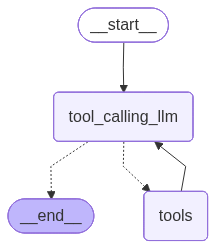

In [28]:
# Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ey7nfpwx9)
 Call ID: ey7nfpwx9
  Args:
    query: recent ai news
    start_date: 2024-01-01
    time_range: day
    topic: news
  multiply (21kv7mrts)
 Call ID: 21kv7mrts
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{'error': ValueError('Error 400: When time_range is set, start_date or end_date cannot be set')}
================================= Tool Message =================================
Name: multiply

50
================================== Ai Message ==================================
Tool Calls:
  tavily_search (spsf5bp67)
 Call ID: spsf5bp67
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (8wznd9a81)
 Call ID: 8wznd9a81
  Ar

Adding Memory In Agentic Graph

In [30]:
response=graph.invoke({"messages":"Hello my name is saumyapraksh"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is saumyapraksh
================================== Ai Message ==================================

Hello Saumya Prakash. It's nice to meet you. Is there something I can help you with or would you like to chat?


In [31]:
response=graph.invoke({"messages":"what is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my name
================================== Ai Message ==================================

I don't have any information about your name. I'm a text-based AI assistant and do not have the ability to access personal data or recall previous conversations. If you would like to share your name with me, I would be happy to chat with you and get to know you better.


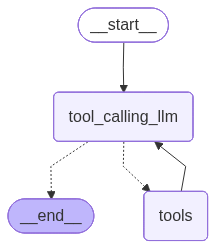

In [32]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver() #memory saver at each check point

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))